In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


: 

In [4]:
data = pd.read_csv("german_credit_data.csv", encoding = 'latin-1')

In [74]:
data.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [75]:
data.shape

(1000, 11)

In [76]:
data['Age'].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [77]:
data.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [78]:
data['Sex'].value_counts()

Sex
male      690
female    310
Name: count, dtype: int64

In [79]:
data['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [80]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [81]:
data['Job'].unique()

array([2, 1, 3, 0])

In [82]:
data.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [83]:
data.duplicated().sum()

np.int64(0)

In [84]:
data = data.dropna().reset_index(drop=True)

In [85]:
data

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [86]:
data.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [87]:
data.drop(columns = 'Unnamed: 0', inplace=True)

In [88]:
data.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

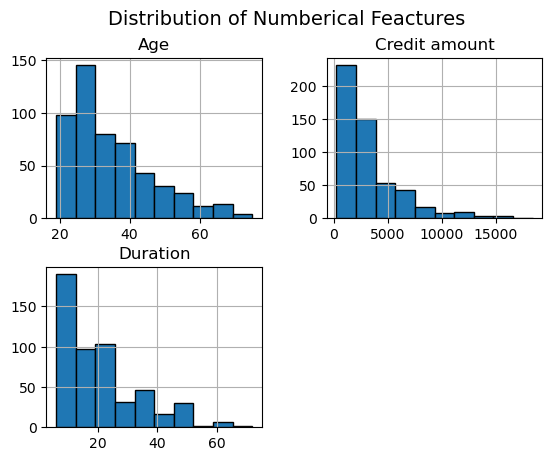

In [89]:
data[["Age","Credit amount","Duration"]].hist(
  bins= 10,
  edgecolor= "black"
)
plt.suptitle("Distribution of Numberical Feactures",fontsize= 14)
plt.show()

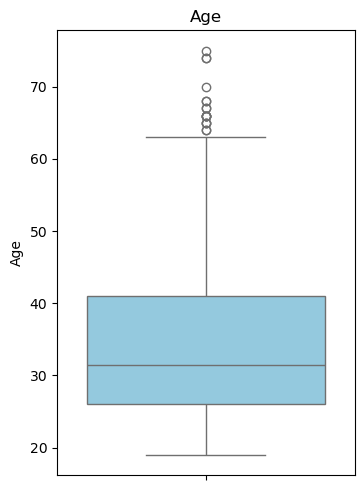

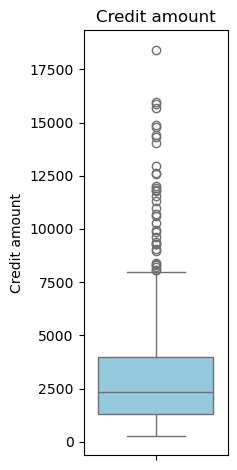

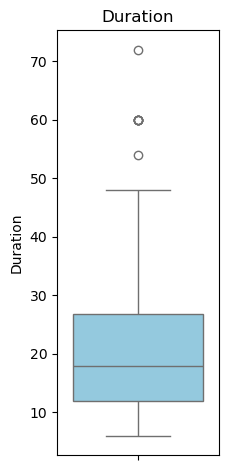

In [90]:
plt.figure(figsize= ( 10,5))
for i, col in enumerate (["Age", "Credit amount", "Duration"]):
  plt.subplot(1, 3, i+ 1)
  sns.boxplot(y = data[col], color ="skyblue")
  plt.title(col)
  
  plt.tight_layout()
  plt.show()
  

In [91]:
data.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [92]:
categorical_cols = ["Sex", "Job","Housing","Saving accounts", "Checking account","Purpose"]

C:\Users\MSI\AppData\Local\Temp\ipykernel_16808\4123995867.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette="Set2", order=data[col].value_counts().index)
C:\Users\MSI\AppData\Local\Temp\ipykernel_16808\4123995867.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette="Set2", order=data[col].value_counts().index)
C:\Users\MSI\AppData\Local\Temp\ipykernel_16808\4123995867.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, palette="Set2", order=data[col].value_counts()

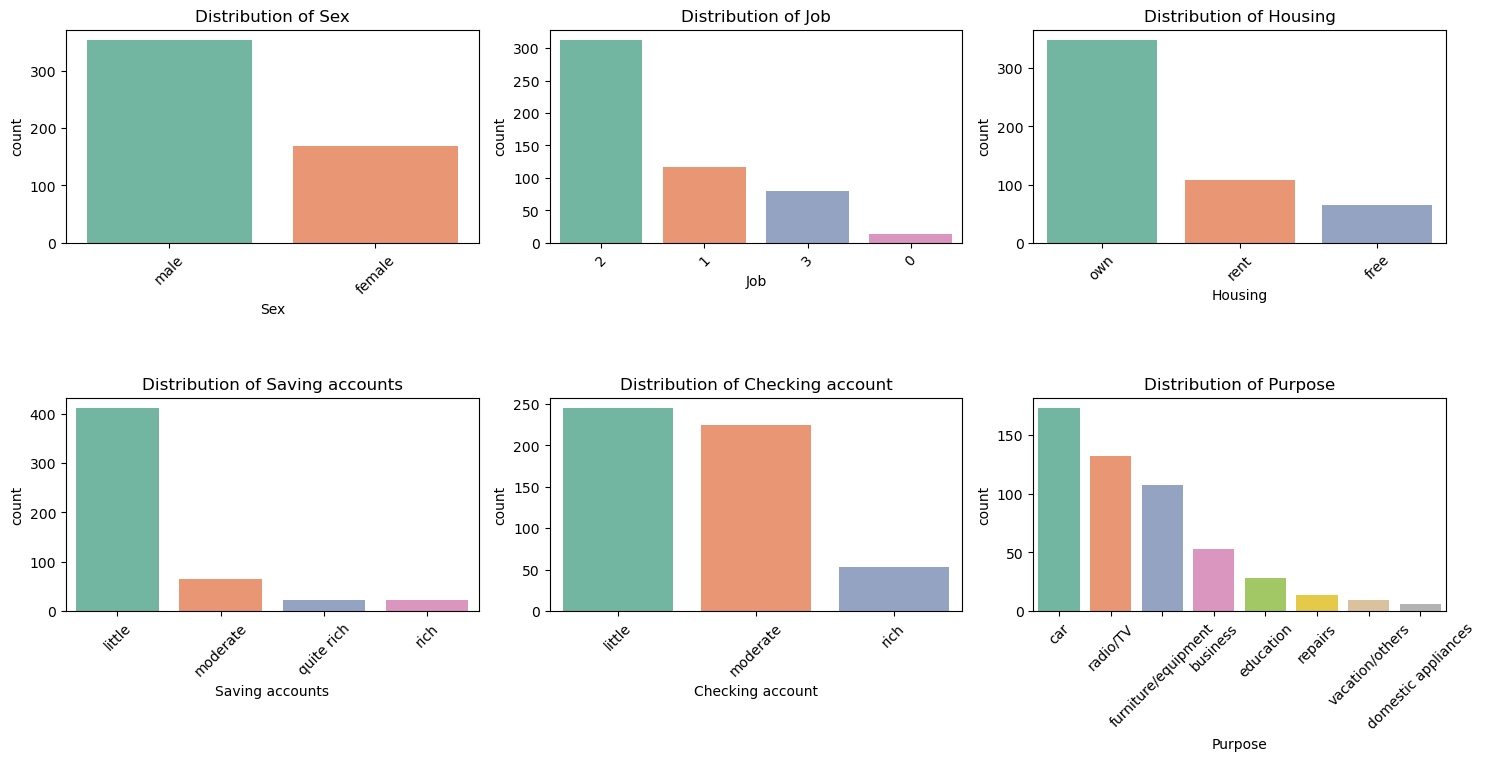

In [93]:

plt.figure(figsize=(15, 10))

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=data, x=col, palette="Set2", order=data[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [94]:
corr = data[["Age","Job","Credit amount","Duration"]].corr()

In [95]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


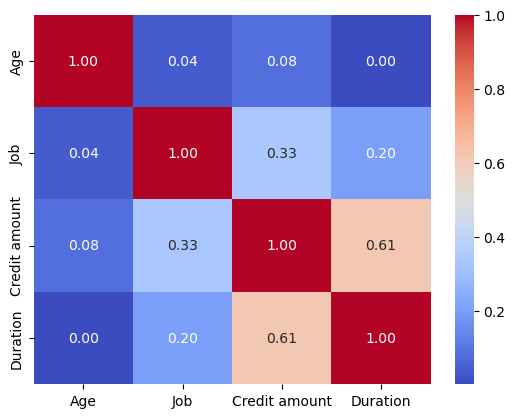

In [96]:
sns.heatmap(corr, annot=True, cmap = "coolwarm", fmt=".2f")
plt.show()

In [97]:
data.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [98]:
data.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [99]:
pd.pivot_table(data, values="Credit amount", index="Housing", columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


In [100]:
data.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

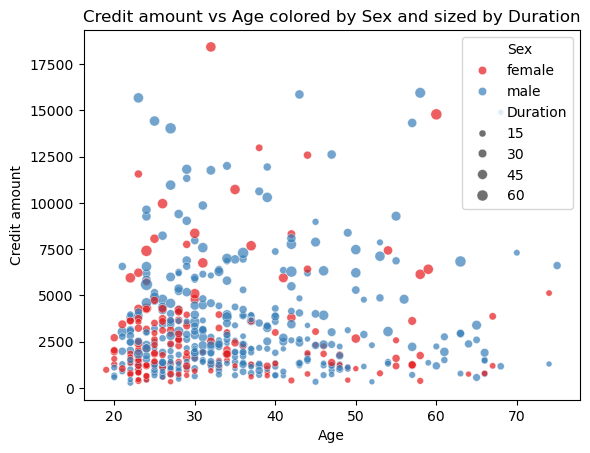

In [101]:
sns.scatterplot(data =data, x="Age", y="Credit amount", hue ="Sex", size="Duration", alpha=0.7, palette="Set1")
plt.title("Credit amount vs Age colored by Sex and sized by Duration")
plt.show()


C:\Users\MSI\AppData\Local\Temp\ipykernel_16808\4256055227.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


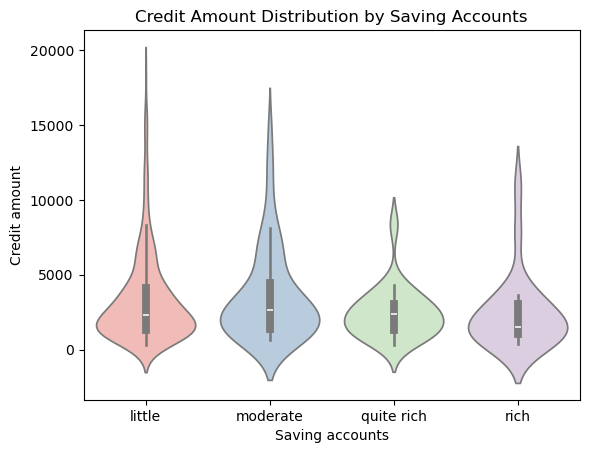

In [102]:
sns.violinplot(
    data=data, x="Saving accounts", y="Credit amount", palette="Pastel1"
)

plt.title("Credit Amount Distribution by Saving Accounts")
plt.show()

In [103]:
data['Risk'].value_counts(normalize=True)*100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

C:\Users\MSI\AppData\Local\Temp\ipykernel_16808\425257872.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= data, x = 'Risk', y =col , palette='Pastel2')
C:\Users\MSI\AppData\Local\Temp\ipykernel_16808\425257872.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= data, x = 'Risk', y =col , palette='Pastel2')
C:\Users\MSI\AppData\Local\Temp\ipykernel_16808\425257872.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= data, x = 'Risk', y =col , palette='Pastel2')


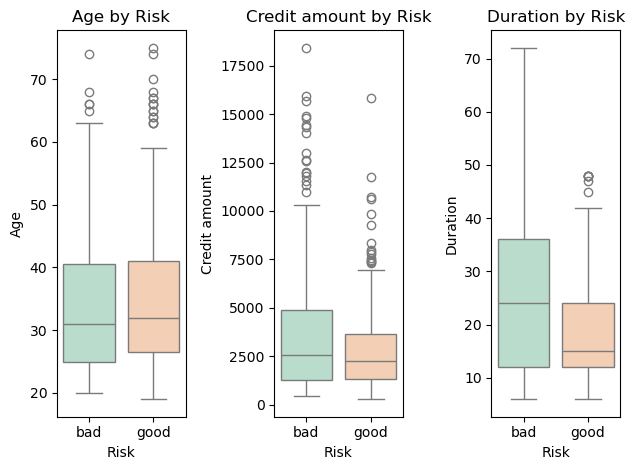

In [104]:

for i, col in enumerate(['Age','Credit amount','Duration']):
  plt.subplot(1, 3, i+1)
  sns.boxplot(data= data, x = 'Risk', y =col , palette='Pastel2')
  plt.title(f"{col} by Risk")
  
plt.tight_layout()
plt.show()

In [105]:
data.groupby("Risk")[['Age','Credit amount','Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [106]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

<Axes: xlabel='Duration', ylabel='count'>

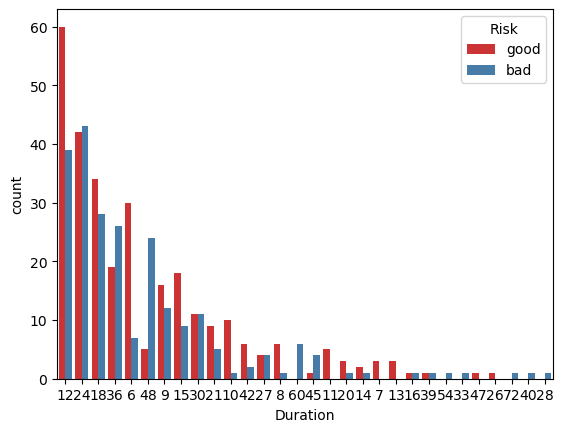

In [107]:
sns.countplot(data=data, x=col, hue="Risk", palette="Set1", order=data[col].value_counts().index)

In [108]:
feature = ["Age", "Sex", "Job","Housing","Saving accounts","Checking account","Credit amount","Duration"]

In [109]:
target = "Risk"

In [110]:
data_model = data[feature + [target]].copy()

In [111]:
data_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [112]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [113]:
cat_cols = data_model.select_dtypes(include="object").columns.drop("Risk")

In [114]:
le_dict = {}

In [115]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [116]:
for col in cat_cols:
  le = LabelEncoder()
  data_model[col] = le.fit_transform(data[col])
  le_dict[col] = le
  joblib.dump(le, f"{col}_encoder.pkl")

In [117]:
le_target = LabelEncoder()

In [118]:
target

'Risk'

In [119]:
data_model[target] = le_target.fit_transform(data_model[target])

In [120]:
data_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [121]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [122]:
data_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [123]:
from sklearn.model_selection import train_test_split

In [124]:
X = data_model.drop(target, axis =1)

In [125]:
y = data_model[target]

In [126]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [127]:
target

'Risk'

In [128]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [129]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, stratify=y, random_state=1)

In [130]:
X_train.shape

(417, 8)

In [131]:
X_test.shape

(105, 8)

In [132]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV



In [133]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(
        model, param_grid, cv=5, scoring="accuracy", n_jobs=1
    )
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [134]:

dt = DecisionTreeClassifier(random_state=1, class_weight="balanced")
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10], 
    "min_samples_leaf": [1, 2, 4],
}

In [135]:
best_dt, acc_dt, params_dt = train_model(
    dt, dt_param_grid, X_train, y_train, X_test, y_test
)

In [136]:
print('Decision Tree Accuracy', acc_dt)

Decision Tree Accuracy 0.580952380952381


In [137]:
print("Best parameters", params_dt)

Best parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [138]:
rf = RandomForestClassifier(random_state=1, class_weight="balanced", n_jobs= -1)

In [ ]:

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [ 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]   
}

In [141]:
best_rf, acc_rf, params_rf = train_model(
    rf, rf_param_grid, X_train, y_train, X_test, y_test
)

In [142]:
print("Random Forest Accuracy", acc_rf)

Random Forest Accuracy 0.6190476190476191


In [143]:
print("Best params", params_rf)

Best params {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [144]:
et = ExtraTreesClassifier(random_state=1, class_weight="balanced", n_jobs= -1)

In [145]:

et_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]   
}

In [146]:
best_et, acc_et,params_et = train_model(et,et_param_grid,X_train, y_train, X_test,y_test)

In [ ]:
print("Extra tree accuracy", acc_et)

In [ ]:
print("Best params:", params_et)

In [147]:
xgb = XGBClassifier(random_state=1, scale__pos_weight=( y_train == 0 ).sum() / (y_train ==1).sum(),use_label_enconder= False, eval_metric="logloss" )

In [164]:
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],   
    "subsample": [0.7, 1],
    "colsample_bytree": [0.7, 1]    
}

In [165]:
params_xgb,acc_xgb,params_xgb = train_model(xgb, xgb_param_grid, X_train,y_train, X_test,y_test)

In [166]:
print("XGB accuracy", acc_xgb)


XGB accuracy 0.6761904761904762


In [162]:
print("Best params", params_xgb)


Best params (XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...), 0.6761904761904762, {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7})


In [167]:
print("Best parmas", params_xgb)

Best parmas {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}


In [168]:
joblib.dump(best_et,"extra_trains_credit_model.pkl")

['extra_trains_credit_model.pkl']

In [7]:
data["Saving accounts"].unique()

array([nan, 'little', 'quite rich', 'rich', 'moderate'], dtype=object)

In [8]:
data["Checking account"].unique()

array(['little', 'moderate', nan, 'rich'], dtype=object)